In [1]:
from src.data_loading import load_data, split_features_target
from src.preprocessing import train_val_split, prepare_numeric_features
from src.model import LinearRegression
from src.evaluate import rmse, r2_score

from src.config import *

import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = load_data("../data/raw/train.csv")

x, y = split_features_target(
    df,
    TARGET_COLUMN,
)

y = np.log1p(y)

In [3]:
x_train, x_val, y_train, y_val = train_val_split(
    x,
    y,
    val_ratio=VAL_RATIO,
)

In [4]:
x_train_np, x_val_np, *_ = prepare_numeric_features(
    x_train,
    x_val,
)

y_train_np = y_train.to_numpy()

y_val_np = y_val.to_numpy()

In [5]:
model = LinearRegression(
    lr=LEARNING_RATE,
    n_epochs=N_EPOCHS,
    reg_lambda=LAMBDA_REG,
)

model.fit(
    x_train_np,
    y_train_np,
    verbose=False,
)

In [6]:
train_pred = model.predict(x_train_np)

val_pred = model.predict(x_val_np)

In [7]:
print("Train RMSE:", rmse(y_train_np, train_pred))
print("Validation RMSE:", rmse(y_val_np, val_pred))

print("Train R2:", r2_score(y_train_np, train_pred))
print("Validation R2:", r2_score(y_val_np, val_pred))

Train RMSE: 0.14882853895989573
Validation RMSE: 0.13633080077305273
Train R2: 0.8639424982484593
Validation R2: 0.8727416515406335


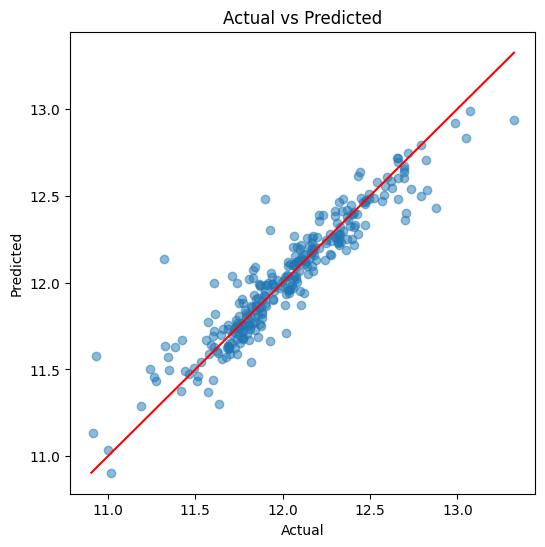

In [8]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_val_np,
    val_pred,
    alpha=0.5,
)

mn = min(y_val_np.min(), val_pred.min())
mx = max(y_val_np.max(), val_pred.max())

plt.plot(
    [mn,mx],
    [mn,mx],
    color="red",
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.savefig(
    FIGURES_DIR / "actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

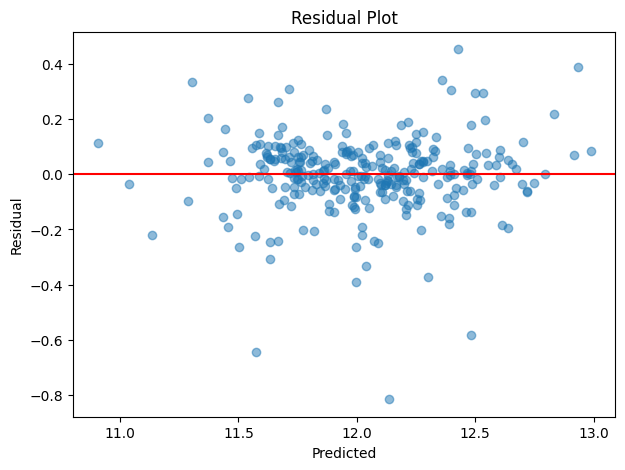

In [9]:
residuals = y_val_np - val_pred

plt.figure(figsize=(7,5))

plt.scatter(
    val_pred,
    residuals,
    alpha=0.5,
)

plt.axhline(
    0,
    color="red",
)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.savefig(
    FIGURES_DIR / "residual_plot.png",
    dpi=300,
)

plt.show()

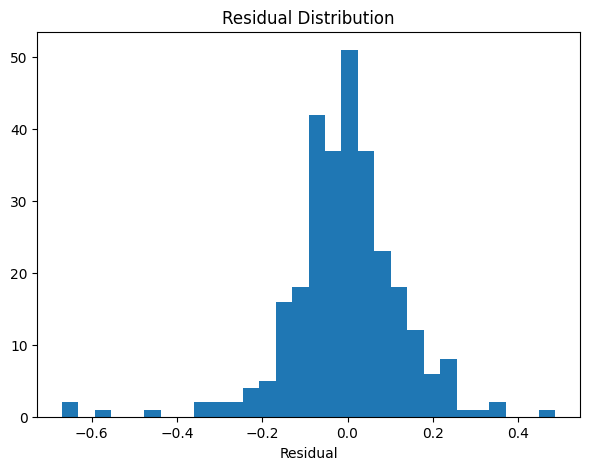

In [20]:
plt.figure(figsize=(7,5))

plt.hist(
    residuals,
    bins=30,
)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.savefig(
    FIGURES_DIR / "residual_distribution.png",
    dpi=300,
)

plt.show()

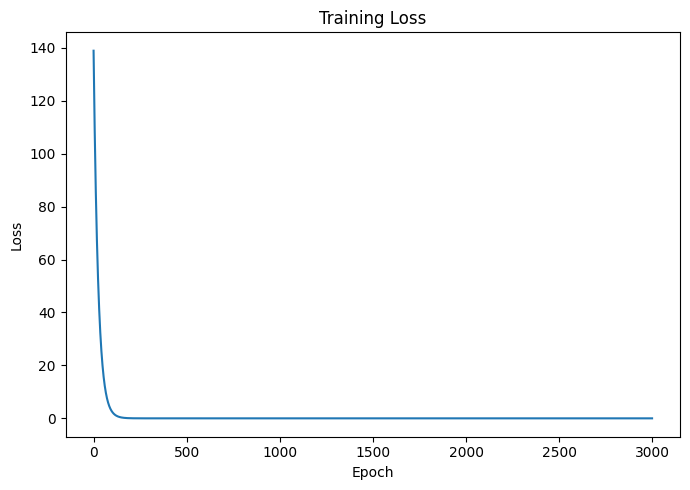

In [12]:
plt.figure(figsize=(7,5))

plt.plot(model.loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "training_loss.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

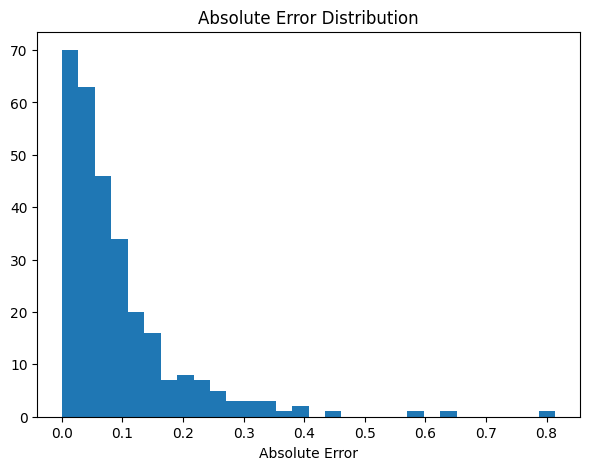

In [13]:
errors = np.abs(y_val_np - val_pred)

plt.figure(figsize=(7,5))

plt.hist(
    errors,
    bins=30,
)

plt.xlabel("Absolute Error")

plt.title("Absolute Error Distribution")

plt.show()